In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import sklearn
import seaborn as sns
df=pd.read_csv("/Users/alokkumardalei/Desktop/ml-assignment/penguins.csv")
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [34]:
df=df.drop(columns=['sex','species','island'])
df.head()
df.info()

df=df.dropna()
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
dtypes: float64(4)
memory usage: 10.9 KB
<class 'pandas.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
dtypes: float64(4)
memory usage: 13.4 KB


In [35]:
x=df.drop(columns=['flipper_length_mm'])
print(x)
y=df['flipper_length_mm']
print(y)

     bill_length_mm  bill_depth_mm  body_mass_g
0              39.1           18.7       3750.0
1              39.5           17.4       3800.0
2              40.3           18.0       3250.0
4              36.7           19.3       3450.0
5              39.3           20.6       3650.0
..              ...            ...          ...
338            47.2           13.7       4925.0
340            46.8           14.3       4850.0
341            50.4           15.7       5750.0
342            45.2           14.8       5200.0
343            49.9           16.1       5400.0

[342 rows x 3 columns]
0      181.0
1      186.0
2      195.0
4      193.0
5      190.0
       ...  
338    214.0
340    215.0
341    222.0
342    212.0
343    213.0
Name: flipper_length_mm, Length: 342, dtype: float64


In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(x_train.shape)
print(x_test.shape)


(273, 3)
(69, 3)


In [37]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train[['body_mass_g']],y_train)
print(model.coef_)
print(model.intercept_)

[0.01540092]
136.39528739188597


In [32]:
print(model.score(x_test[['body_mass_g']],y_test))


0.7827917699032012


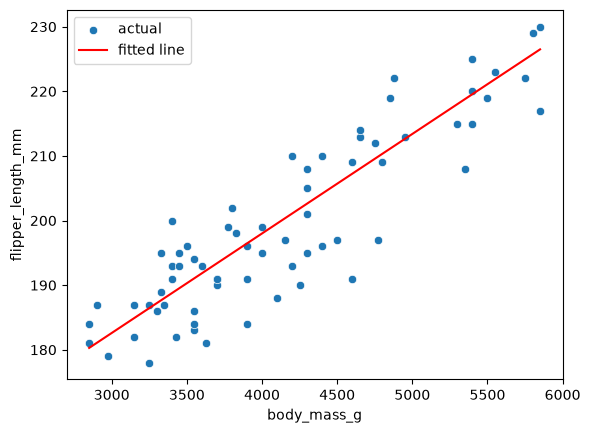

In [41]:
sns.scatterplot(x=x_test['body_mass_g'], y=y_test, label='actual')
sns.lineplot(x=x_test['body_mass_g'], y=model.predict(x_test[['body_mass_g']]),
             color='red', label='fitted line')
plot.show()

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(x_test[['body_mass_g']])

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:  ", r2_score(y_test, y_pred))

MAE:  5.115486048431881
RMSE: 6.291581570202106
R2:   0.7827917699032012
